last modified date : 2026.05  
제작 : 모두의연구소

# Day 2 실습 — Advanced·Modular RAG + RAGAS 평가

# 들어가며

Day 1에서는 가장 기본형인 **Naive RAG** 파이프라인을 직접 구현해 보았습니다. 이번 실습에서는 한국어 QA 벤치마크 **KorQuAD v1** 데이터셋 위에서 **Advanced·Modular RAG** 의 핵심 기법(Multi-Query, RAG-Fusion, HyDE, Reranking, Self-RAG)을 단계적으로 적용하고, 그 결과를 **RAGAS** 로 정량 평가합니다.

이번 실습이 끝나면 다음을 직접 말할 수 있게 됩니다.
- Naive RAG 대비 **어떤 단계**를 보강하면 정답률이 올라가는가
- Multi-Query / RAG-Fusion / HyDE / Reranker / Self-RAG 는 각각 **어떤 코드 라인**으로 적용하는가
- RAGAS 의 4대 지표(Faithfulness · Answer Relevance · Context Precision · Context Recall)는 어떻게 계산되고 어떻게 읽는가
- 내 RAG 가 ‘얼마나 좋아졌는지’를 **숫자로** 보여주는 방법

## Step 0 : 설치와 준비  
Day 1과 동일하게 Colab에서 진행한다고 가정합니다.

In [2]:
# Colab pre-installed langchain 0.3 / ragas 0.1~0.4 를 ragas 0.2.10 호환 조합으로 정리합니다.
# 처음 실행 시 약 3~5분 걸립니다. 진행률 출력을 보면서 기다리세요 (멈춘 게 아닙니다).

# 1) 기존 langchain / ragas 패키지 제거 — 버전 충돌로 인한 pip resolver 백트래킹 방지
!pip uninstall -y ragas ragas-experimental langchain langchain-core langchain-community langchain-openai langchain-text-splitters langchain-chroma

# 2) 0.2 시리즈 패치 버전까지 핀 설치 — resolver 부담 최소화 (-q 제거해서 진행률 보이게)
!pip install --no-cache-dir \
    "ragas==0.2.10" \
    "langchain==0.2.17" \
    "langchain-core==0.2.43" \
    "langchain-community==0.2.19" \
    "langchain-openai==0.1.25" \
    "langchain-text-splitters==0.2.4" \
    "langchain-chroma==0.1.4" \
    pypdf chromadb tiktoken sentence-transformers datasets nest_asyncio pandas

Found existing installation: ragas 0.4.3
Uninstalling ragas-0.4.3:
  Successfully uninstalled ragas-0.4.3
Found existing installation: langchain 1.3.2
Uninstalling langchain-1.3.2:
  Successfully uninstalled langchain-1.3.2
Found existing installation: langchain-core 1.4.0
Uninstalling langchain-core-1.4.0:
  Successfully uninstalled langchain-core-1.4.0
Found existing installation: langchain-community 0.4.2
Uninstalling langchain-community-0.4.2:
  Successfully uninstalled langchain-community-0.4.2
Found existing installation: langchain-openai 1.2.2
Uninstalling langchain-openai-1.2.2:
  Successfully uninstalled langchain-openai-1.2.2
Found existing installation: langchain-text-splitters 1.1.2
Uninstalling langchain-text-splitters-1.1.2:
  Successfully uninstalled langchain-text-splitters-1.1.2
Found existing installation: langchain-chroma 1.1.0
Uninstalling langchain-chroma-1.1.0:
  Successfully uninstalled langchain-chroma-1.1.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.7/175.

In [1]:
import os
# chromadb 익명 통계 전송 끄기 — posthog SDK 인자 충돌로 ERROR 로그가 뜨는 것 방지
os.environ["ANONYMIZED_TELEMETRY"] = "False"

import nest_asyncio
nest_asyncio.apply()  # RAGAS가 Colab의 비동기 이벤트 루프와 충돌하지 않도록

In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

## Step 1 : KorQuAD v1 위에서 Naive RAG 베이스라인 만들기

Day 1에서 만든 RAG 파이프라인을 한국어 QA 벤치마크 **KorQuAD v1** 위에 다시 한 번 올립니다. 이후 단계는 모두 이 베이스라인 위에 ‘덧붙이는’ 방식입니다.

- HuggingFace `datasets` 로 KorQuAD v1 자동 다운로드 (별도 PDF 업로드 불필요)
- 일부만 샘플링해 토큰 비용 통제 (unique context 약 200개)
- Embedding → VectorStore → Retriever → LLM
- 검색 전략은 단순 `similarity` (top-k)

**📥 데이터셋**: <https://huggingface.co/datasets/KorQuAD/squad_kor_v1>

In [3]:
from datasets import load_dataset
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
import tiktoken, random

tokenizer = tiktoken.get_encoding("cl100k_base")
def tiktoken_len(text):
    return len(tokenizer.encode(text))

# 1) 데이터셋 로드 + 2000개 샘플링 + context 중복 제거 → unique 약 800개
#    (Vector DB 가 크면 Reranker 의 정밀도 개선 효과가 더 또렷하게 보입니다.
#     인덱싱 토큰 비용 약 0.01 USD 추가)
raw_ds = load_dataset("squad_kor_v1", split="validation").shuffle(seed=42).select(range(2000))

unique = {}
for ex in raw_ds:
    if ex["context"] not in unique:
        unique[ex["context"]] = ex["title"]
context_docs = [Document(page_content=c, metadata={"title": t}) for c, t in unique.items()]

# 2) chunk 단위로 분할 (KorQuAD context는 짧지만 길이 균질화를 위해 splitter 사용)
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0, length_function=tiktoken_len)
docs = splitter.split_documents(context_docs)

# 3) Embedding & Chroma 적재 — chunk 약 800개를 한 번에 넣으면 chromadb 의 batch limit
#    (Colab 환경에서 보통 5461) 또는 OpenAI rate limit 에 걸릴 수 있어
#    100개씩 배치로 add_documents 합니다.
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
db = Chroma(embedding_function=embedding)
BATCH = 100
for i in range(0, len(docs), BATCH):
    db.add_documents(docs[i:i+BATCH])

# 4) Retriever (Naive: similarity)
naive_retriever = db.as_retriever(search_type="similarity", search_kwargs={"k": 3})

# 5) LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print(f"베이스라인 준비 완료 — unique context: {len(context_docs)}, chunks: {len(docs)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


베이스라인 준비 완료 — unique context: 847, chunks: 1264


베이스라인 RAG로 간단한 질의를 던져 답이 나오는지 확인합니다.

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

RAG_PROMPT = ChatPromptTemplate.from_template(
    "다음 문서를 참고해 질문에 한국어로 간결하게 답하세요. 문서에 없는 내용은 만들지 마세요.\n\n"
    "[문서]\n{context}\n\n"
    "[질문]\n{question}\n\n"
    "[답변]"
)

def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

naive_chain = (
    {"context": naive_retriever | format_docs,
     "question": RunnablePassthrough()}
    | RAG_PROMPT
    | llm
    | StrOutputParser()
)

# 데이터셋에서 첫 질문 하나를 뽑아 테스트
TEST_Q = raw_ds[0]["question"]
print("Q:", TEST_Q)
print("A:", naive_chain.invoke(TEST_Q))

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Q: 2004년 이명박이 서울시장 재직시절 전면적으로 개선한 것은?
A: 대중교통체계입니다.


## Step 2 : Pre-retrieval 강화 — Multi-Query Retrieval  

사용자가 던진 질문 하나로만 검색하면 ‘다른 표현’으로 적힌 정답을 놓칠 수 있습니다. **Multi-Query Retrieval**은 LLM에게 ‘같은 의도의 다른 질문 N개’를 만들게 시킨 뒤, 각 질문으로 병렬 검색하고 결과를 합칩니다.

LangChain은 이를 한 클래스로 제공합니다.

In [5]:
from langchain.retrievers.multi_query import MultiQueryRetriever
import logging
logging.basicConfig()
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=db.as_retriever(search_kwargs={"k": 3}),
    llm=ChatOpenAI(model="gpt-4o-mini", temperature=0),
)

# 어떤 ‘유사 질문’으로 확장되는지 로그로 확인 가능
docs_mq = multi_query_retriever.invoke(TEST_Q)
print(f"검색된 문서 수: {len(docs_mq)}")
print("---")
print(docs_mq[0].page_content[:300])

INFO:langchain.retrievers.multi_query:Generated queries: ['2004년 이명박 서울시장이 재직할 때 어떤 주요 개선 사항이 있었나요?  ', '이명박이 2004년에 서울시장으로서 추진한 주요 정책이나 변화는 무엇인가요?  ', '2004년 이명박 서울시장 재임 중에 이루어진 주요 개선 프로젝트는 어떤 것들이 있나요?']


검색된 문서 수: 6
---
2010년 한나라당 당내경선에서 나경원, 김충환 등의 경쟁자를 물리치고, 민선 5기 지방선거에서 서울시장 재선에 도전했다. 6월 2일에 치뤄진 지방선거에서 개표 초반에 한명숙 후보에게 뒤지다가, 후반 강남 3구의 개표가 시작되면서 역전하여 민선 5기 제34대 서울특별시장으로 재선되었다. 구체적으로 강남구(+59,206, +25.68%), 서초구(+43,820, +23.66%), 송파구(+23,814, +8.19%), 강동구(+11,097, +5.33%), 용산구(+8,579, +8.24%), 양천구(+1,078, +0.51%), 영


## Step 2.5 : RAG-Fusion — Multi-Query + RRF로 묶어내기

Day2_1 노트에서 “꼭 짚고 가라”고 했던 패턴 중 하나가 **RAG-Fusion** 입니다. Step 2의 Multi-Query는 ‘유사 질문 N개로 병렬 검색’ 까지만 했는데, **RAG-Fusion** 은 그 N개 검색 결과를 **Reciprocal Rank Fusion (RRF)** 라는 간단한 공식으로 합쳐 ‘여러 쿼리에서 공통으로 상위에 떴던 문서’ 를 최상단으로 끌어올립니다.

RRF 점수 공식:

$$
\text{score}(d) = \sum_{i=1}^{N} \frac{1}{k + \text{rank}_i(d)}
$$

- $\text{rank}_i(d)$ : i번째 쿼리의 결과에서 문서 $d$ 의 순위 (1부터)
- $k$ : 스무딩 상수 (관례적으로 60)

아래 셀에서는 (1) sub-query 생성, (2) 각 sub-query 로 검색, (3) **RRF 함수는 여러분이 직접 채우기**, (4) 결과 확인까지 한 번에 해봅니다.

In [6]:
from collections import defaultdict

# (1) sub-query 생성 — Multi-Query 가 내부적으로 하는 일을 명시적으로 노출 (한국어)
SUBQUERY_PROMPT = ChatPromptTemplate.from_template(
    "당신은 검색 보조 AI 입니다. 다음 질문과 의미는 같지만 표현이 다른 4개의 한국어 검색 쿼리를 만드세요. "
    "오직 4개의 쿼리만 한 줄에 하나씩 출력하고, 번호나 다른 설명은 붙이지 마세요.\n\n질문: {question}"
)

def fan_out_queries(question, n=4):
    raw = (SUBQUERY_PROMPT | llm | StrOutputParser()).invoke({"question": question})
    return [q.strip() for q in raw.split("\n") if q.strip()][:n]


# (2) RRF 함수 — TODO: 여러분이 직접 채워보세요
def reciprocal_rank_fusion(results_per_query, k=60, top_k=3):
    """
    results_per_query : List[List[Document]]  쿼리별 검색 결과(순위 순).
    k                 : RRF smoothing 상수 (관례적으로 60).
    top_k             : 최종 반환할 문서 개수.
    """
    scores = defaultdict(float)
    docs_by_key = {}

    # TODO 1: 각 쿼리의 결과 리스트를 순회하면서 문서마다 RRF 점수를 누적해 보세요.
    #   힌트:
    #     for docs in results_per_query:
    #         for rank, doc in enumerate(docs):  # rank 는 0부터
    #             key = doc.page_content
    #             scores[key] += 1.0 / (k + rank + 1)
    #             docs_by_key[key] = doc


    # TODO 2: scores 값이 큰 순서로 정렬해서 상위 top_k 개의 Document 를 반환하세요.
    #   힌트:
    #     ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    #     return [docs_by_key[k] for k, _ in ranked[:top_k]]

    return []


# (3) 한 번 돌려보기
sub_queries = fan_out_queries(TEST_Q)
print(f"확장 질문 {len(sub_queries)}개:")
for q in sub_queries:
    print(" -", q)

results_per_q = [db.similarity_search(q, k=5) for q in sub_queries]
fused = reciprocal_rank_fusion(results_per_q, k=60, top_k=3)

print("\nRAG-Fusion top-1 문서:")
print(fused[0].page_content[:300] if fused else "(아직 TODO 가 비어 있어 결과가 없습니다)")

확장 질문 4개:
 - 2004년 이명박 서울시장 재직 중 개선한 사항은?
 - 이명박이 2004년 서울시장으로서 개선한 내용은 무엇인가?
 - 2004년 서울시장 이명박이 전면적으로 개선한 것은 어떤 것인가?
 - 이명박 서울시장 재직 시절 2004년에 개선한 것은 무엇인지?

RAG-Fusion top-1 문서:
(아직 TODO 가 비어 있어 결과가 없습니다)


## Step 3 : 패턴 ② HyDE — 가상의 ‘정답’으로 진짜 정답 찾기  

질문은 짧은 의문문, 정답은 긴 평서문이라 둘의 임베딩이 의외로 멀 수 있습니다. **HyDE(Hypothetical Document Embeddings)** 는 검색 전에 LLM에게 ‘가상의 정답’을 쓰게 한 뒤, 그 가상 답변을 임베딩해서 검색합니다.

직접 구현해 보겠습니다.

In [7]:
HYDE_PROMPT = ChatPromptTemplate.from_template(
    "당신은 해당 분야 전문가입니다. 다음 질문에 대해 그럴듯한 한국어 답변 한 문단을 작성하세요. "
    "확실하지 않다면 가장 합리적인 추측을 적어주세요.\n\n"
    "질문: {question}\n\n가상 답변:"
)

hyde_generator = HYDE_PROMPT | llm | StrOutputParser()

def hyde_retrieve(question, k=3):
    """질문 → 가상의 답변 → 가상 답변을 임베딩해 검색"""
    hypothetical = hyde_generator.invoke({"question": question})
    return db.similarity_search(hypothetical, k=k), hypothetical

docs_hyde, hyp = hyde_retrieve(TEST_Q)
print("가상 답변(HyDE):\n", hyp[:300], "\n---")
print("검색된 문서 수:", len(docs_hyde))
print("첫 문서:", docs_hyde[0].page_content[:200])

가상 답변(HyDE):
 2004년 이명박이 서울시장으로 재직하던 시절, 그는 서울의 교통 체계를 전면적으로 개선하는 데 주력했습니다. 특히, 그는 '서울시 교통체계 개선 계획'을 통해 대중교통의 효율성을 높이고, 도로 혼잡을 줄이기 위한 다양한 정책을 시행했습니다. 이 과정에서 지하철 노선 확장과 버스 전용 차선 도입, 그리고 자전거 도로의 확충 등이 이루어졌습니다. 이러한 노력은 서울시민의 이동 편의를 증대시키고, 대기 오염 문제를 완화하는 데 기여했습니다. 
---
검색된 문서 수: 3
첫 문서: 2004년 서울시장 재직시절 대중교통체계를 전면적으로 개선하였다. 거리비례제를 도입하여 교통수단에 관계없이 이동한 거리에 비례해서 요금을 지불하게 바뀌면서 환승으로 인한 추가적인 교통비 부담이 없어졌다. 그 외에도 서울시 버스를 4종류로 나누고 버스 전용차로를 도로 중앙으로 옮기는 등의 많은 변화가 일시에 일어나면서 초기엔 시행착오로 인한 큰 불편을 겪기도


## Step 4 : Post-retrieval 강화 — Cross-Encoder Reranking (multilingual)

검색 결과를 그대로 LLM 에 넘기지 않고, **Cross-encoder reranker** 가 (질문, 문단)을 함께 보면서 진짜 관련도를 다시 점수화합니다. 정밀도가 15~30% 개선되는 게 일반적인 보고입니다.

한국어 문서를 다루고 있으므로 다국어를 지원하는 cross-encoder 를 사용합니다. `BAAI/bge-reranker-v2-m3` 는 한국어를 포함한 100개 이상 언어에서 동작합니다. 처음 실행 시 모델 다운로드(~2GB)가 발생합니다.

In [8]:
from sentence_transformers import CrossEncoder

# 다국어 cross-encoder (한국어 포함)
reranker = CrossEncoder("BAAI/bge-reranker-v2-m3")

def rerank(query, docs, top_k=3):
    """검색된 docs 를 cross-encoder 로 다시 점수화해 상위 top_k 만 반환"""
    pairs = [(query, d.page_content) for d in docs]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)
    return [d for d, _ in ranked[:top_k]]

candidates = db.as_retriever(search_kwargs={"k": 10}).invoke(TEST_Q)
top3 = rerank(TEST_Q, candidates, top_k=3)
print(f"후보 {len(candidates)}개 → Reranker 로 상위 3개 선별")
print("최상위 문서:", top3[0].page_content[:200])

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

후보 10개 → Reranker 로 상위 3개 선별
최상위 문서: 2004년 서울시장 재직시절 대중교통체계를 전면적으로 개선하였다. 거리비례제를 도입하여 교통수단에 관계없이 이동한 거리에 비례해서 요금을 지불하게 바뀌면서 환승으로 인한 추가적인 교통비 부담이 없어졌다. 그 외에도 서울시 버스를 4종류로 나누고 버스 전용차로를 도로 중앙으로 옮기는 등의 많은 변화가 일시에 일어나면서 초기엔 시행착오로 인한 큰 불편을 겪기도


## Step 5 : Advanced RAG 체인 조립  

위에서 만든 컴포넌트들을 하나의 체인으로 묶습니다. **‘넓게 검색 → Reranker로 좁히기 → LLM 답변’** 패턴이 가장 흔히 쓰입니다.

In [9]:
def advanced_rag(question):
    # 1) 후보를 넓게 검색 (k=10)
    candidates = db.as_retriever(search_kwargs={"k": 10}).invoke(question)
    # 2) Cross-encoder 로 진짜 관련도 재정렬 후 상위 3개
    top = rerank(question, candidates, top_k=3)
    # 3) 프롬프트에 컨텍스트로 주입 → 답변
    context = format_docs(top)
    answer = (RAG_PROMPT | llm | StrOutputParser()).invoke(
        {"context": context, "question": question})
    return answer, top

ans_adv, ctx_adv = advanced_rag(TEST_Q)
print("Advanced RAG 답변:\n", ans_adv)

Advanced RAG 답변:
 대중교통체계입니다.


## Step 5.5 : Self-RAG — 검색 필요성 판단 + 답변 자가 비평

Day2_1 노트에서 강조한 또 하나의 핵심 패턴, **Self-RAG** 입니다. Self-RAG의 핵심은 **LLM이 검색·답변 과정에 스스로 비평(critique)을 끼워 넣는다**는 점입니다.

이번 셀에서는 공식 Self-RAG 모델을 따로 받지 않고, **세 개의 작은 LLM 프롬프트**로 같은 흐름을 흉내내 봅니다.

1. **Retrieve 결정** — 질문이 들어오면, 외부 검색이 필요한지 LLM이 먼저 판단합니다. (`YES`/`NO` 한 단어)
2. **답변 생성** — `YES` 면 일반 RAG, `NO` 면 검색 없이 LLM 단독 답변.
3. **답변 자가 비평** — 생성된 답변이 컨텍스트에 충분히 근거하는지 LLM이 점검합니다. (`SUPPORTED` / `NOT_SUPPORTED`)
4. **보완 재시도** — `NOT_SUPPORTED` 면 Step 3의 **HyDE** 로 검색 쿼리를 바꿔 한 번 더 시도합니다.

코드 골격은 제공해 두었고, **두 군데 핵심 프롬프트만 여러분이 직접 채워주세요.**

In [10]:
# Self-RAG : retrieve 판단 + 자가 비평 + HyDE 재시도

# (1) 검색 필요성 판단 프롬프트 — TODO 1
RETRIEVE_DECISION_PROMPT = ChatPromptTemplate.from_template(
    # TODO: 사용자 질문이 외부 문서 검색이 필요하면 YES,
    #       일반 상식·계산·정의 등 LLM 자체 지식으로 답할 수 있으면 NO
    #       오직 한 단어(YES 또는 NO)만 출력하도록 한국어 프롬프트를 채우세요.
    ""
)

# (2) 답변 자가 비평 프롬프트 — TODO 2
CRITIQUE_PROMPT = ChatPromptTemplate.from_template(
    # TODO: [문서] {context} 와 [답변] {answer} 가 주어졌을 때,
    #       답변이 문서 내용으로 충분히 뒷받침되면 SUPPORTED,
    #       아니면 NOT_SUPPORTED — 한 단어만 출력하도록 한국어 프롬프트를 채우세요.
    ""
)


def self_rag(question, max_retries=1, verbose=True):
    decision = (RETRIEVE_DECISION_PROMPT | llm | StrOutputParser()).invoke(
        {"question": question}).strip().upper()
    if verbose:
        print(f"[1] Retrieve 필요? -> {decision}")

    if decision.startswith("NO"):
        ans = llm.invoke(question).content
        if verbose:
            print("[2] LLM 단독 답변 사용")
        return ans, []

    docs = db.as_retriever(search_kwargs={"k": 3}).invoke(question)

    for attempt in range(max_retries + 1):
        answer = (RAG_PROMPT | llm | StrOutputParser()).invoke(
            {"context": format_docs(docs), "question": question})
        critique = (CRITIQUE_PROMPT | llm | StrOutputParser()).invoke(
            {"context": format_docs(docs), "answer": answer}).strip().upper()
        if verbose:
            print(f"[3] 시도 {attempt+1} — 자가 비평: {critique}")

        if "NOT" not in critique:
            return answer, docs

        if attempt < max_retries:
            hyp = hyde_generator.invoke({"question": question})
            docs = db.similarity_search(hyp, k=3)
            if verbose:
                print("[4] NOT_SUPPORTED -> HyDE 가상 답변으로 재검색")

    return answer, docs


ans_sr, ctx_sr = self_rag(TEST_Q)
print("\n=== Self-RAG 최종 답변 ===")
print(ans_sr)

[1] Retrieve 필요? -> HELLO! HOW CAN I ASSIST YOU TODAY?
[3] 시도 1 — 자가 비평: HELLO! HOW CAN I ASSIST YOU TODAY?

=== Self-RAG 최종 답변 ===
대중교통체계입니다.


## Step 6 : RAGAS 평가용 데이터셋 만들기

RAGAS 는 네 가지 자료가 필요합니다.
- `user_input` — 사용자 질문
- `response`   — RAG 가 생성한 답변
- `retrieved_contexts` — RAG 가 참고한 문서들
- `reference`  — 모범 답안 (Ground Truth)

**KorQuAD 는 사람이 작성한 정답이 데이터셋에 이미 포함**되어 있어, `reference` 를 따로 작성할 필요 없이 그대로 가져다 씁니다. 같은 질문 셋을 **Naive RAG** 와 **Advanced RAG** 두 가지로 풀고 결과를 비교합니다.

토큰 비용 통제를 위해 평가 질문은 5개만 사용합니다. (늘리려면 `EVAL_N` 변경)

In [11]:
# 평가용 질문/정답 자동 추출 (KorQuAD)
EVAL_N = 20  # 평가 질문 수. 표본 분산을 줄이려 20개로 설정. 줄이려면 5~10.
eval_samples = list(raw_ds)[:EVAL_N]
questions = [ex["question"] for ex in eval_samples]
ground_truths = [ex["answers"]["text"][0] for ex in eval_samples]

# Naive RAG 로 답변 + 컨텍스트 수집
naive_answers, naive_contexts = [], []
for q in questions:
    ctx = naive_retriever.invoke(q)
    a = (RAG_PROMPT | llm | StrOutputParser()).invoke(
        {"context": format_docs(ctx), "question": q})
    naive_answers.append(a)
    naive_contexts.append([d.page_content for d in ctx])

# Advanced RAG 로 답변 + 컨텍스트 수집
adv_answers, adv_contexts = [], []
for q in questions:
    a, ctx = advanced_rag(q)
    adv_answers.append(a)
    adv_contexts.append([d.page_content for d in ctx])

print(f"데이터셋 준비 완료 — {EVAL_N}개 질문 × 2개 파이프라인")

데이터셋 준비 완료 — 20개 질문 × 2개 파이프라인


In [12]:
from datasets import Dataset

def make_dataset(answers, contexts):
    return Dataset.from_dict({
        "user_input":         questions,
        "response":           answers,
        "retrieved_contexts": contexts,
        "reference":          ground_truths,
    })

naive_ds = make_dataset(naive_answers, naive_contexts)
adv_ds   = make_dataset(adv_answers,   adv_contexts)

## Step 7 : RAGAS로 4대 지표 계산하기  

Judge LLM은 `gpt-4o-mini`로, 임베딩은 `text-embedding-3-small`로 설정합니다.  
(Judge에 더 강한 모델을 쓰면 채점은 더 정교해지지만 비용이 늘어납니다.)

In [13]:
from ragas import evaluate
from ragas.metrics import (
    faithfulness, answer_relevancy,
    context_precision, context_recall,
)

judge_llm  = ChatOpenAI(model="gpt-4o-mini", temperature=0)
judge_emb  = OpenAIEmbeddings(model="text-embedding-3-small")
metrics    = [faithfulness, answer_relevancy,
              context_precision, context_recall]

print("=== Naive RAG 채점 ===")
naive_result = evaluate(naive_ds, metrics=metrics,
                        llm=judge_llm, embeddings=judge_emb,
                        raise_exceptions=False)

print("=== Advanced RAG 채점 ===")
adv_result = evaluate(adv_ds, metrics=metrics,
                      llm=judge_llm, embeddings=judge_emb,
                      raise_exceptions=False)

=== Naive RAG 채점 ===


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

=== Advanced RAG 채점 ===


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

In [14]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

naive_df = naive_result.to_pandas()
adv_df   = adv_result.to_pandas()

def summary(df, label):
    cols = ["faithfulness", "answer_relevancy",
            "context_precision", "context_recall"]
    avg = df[cols].mean()
    avg.name = label
    return avg

compare = pd.concat([summary(naive_df, "Naive RAG"),
                     summary(adv_df,   "Advanced RAG")], axis=1)
print(compare.round(3))
print("\nDelta (Advanced - Naive):")
print((compare["Advanced RAG"] - compare["Naive RAG"]).round(3))

                   Naive RAG  Advanced RAG
faithfulness           0.575         0.825
answer_relevancy       0.297         0.251
context_precision      0.642         0.792
context_recall         0.700         0.800

Delta (Advanced - Naive):
faithfulness         0.250
answer_relevancy    -0.045
context_precision    0.150
context_recall       0.100
dtype: float64


### 결과 해석 가이드

위 비교표를 처음 보면 **‘Advanced 가 더 나쁜 거 아닌가?’** 라는 착각을 하기 쉽습니다. KorQuAD 위에서의 결과 해석 방법을 정리합니다.

**1. `context_precision` 의 개선 (+) 이 Advanced RAG 의 핵심 효과**
검색 결과의 ‘상단’에 정답 문단을 두는 일을 Reranker 가 잘 했다는 의미. Δ가 0.05~0.15 정도면 잘 작동.

**2. `context_recall = 1.0` 으로 포화될 수 있다**
unique context 가 800개 정도면 Naive top-3 에도 정답이 거의 항상 들어옵니다. 이 지표는 더 큰 DB(수만 문서)에서 차이가 드러납니다.

**3. `faithfulness` 가 살짝 떨어질 수 있다**
Reranker 가 컨텍스트를 ‘짧고 집중’ 시키면 LLM이 그 좁은 정보에서 답을 만들 때 일부 주장이 “미뒷받침” 으로 채점되어 점수가 약간 내려갈 수 있음. **정상 범위 (-0.1 이내)**.

**4. `answer_relevancy` 가 0.2~0.4 로 낮은 이유 — KorQuAD 의 구조적 특성**
KorQuAD 정답은 *‘대중교통체계’* 같이 한 단어~한 구절. RAG 답변도 짧게 나오는데, RAGAS 의 `answer_relevancy` 는 **답변에서 질문을 역추론**해 원래 질문과의 유사도를 계산합니다. 답변이 한 단어면 역추론이 흐려져 점수가 낮아집니다. **모델 잘못이 아닌 데이터셋 특성**.

**5. 표본 20개로도 Δ가 ±0.05 이내면 ‘차이 없음’으로 봐야 한다**
20문항에서 ±0.05 는 표본 noise. 더 확실한 판단이 필요하면 `scipy.stats.ttest_rel` 로 통계 검정을 하거나 50~100문항으로 늘려야 합니다.

**6. 한국어 짧은 정답 벤치마크의 한계**
KorQuAD/KLUE-MRC 처럼 정답이 짧은 extractive QA 벤치마크는 `context_precision` 위주로 평가 효과를 봐야 하고, `answer_relevancy` 는 절대값보다 **Naive 대비 상대 변화**로 읽어야 합니다.

### Quiz  
위 표에서 Advanced RAG가 가장 크게 개선한 지표는 무엇인가요? 그리고 그 지표는 우리가 적용한 **어떤 기법**과 가장 직접적으로 연결될까요?  

**Answer (예시)**:  
보통 `context_precision`이 가장 크게 오릅니다. 이는 우리가 추가한 **Reranker**가 ‘진짜 관련도가 높은 문서를 상위에 두는 일’을 잘 했다는 의미입니다.  `context_recall`은 **Multi-Query**가 검색 폭을 넓혔다면 같이 오릅니다.  `faithfulness`와 `answer_relevancy`는 컨텍스트 품질이 올라가면 부수적으로 개선됩니다.

## Step 8 : (선택) 평가 데이터를 LLM으로 자동 생성하기  

현업에서는 모범 답안(`reference`)을 사람이 직접 작성하는 게 가장 큰 부담입니다.  
RAGAS는 **원본 문서만 주면 Question·Reference·Context 한 세트를 자동으로 만들어 주는** 기능을 제공합니다.  
자세한 사용법은 공식 문서를 참고하세요.

https://docs.ragas.io/en/stable/getstarted/rag_testset_generation/

In [16]:
!git clone https://huggingface.co/datasets/vibrantlabsai/Sample_Docs_Markdown #문서 다운로드

Cloning into 'Sample_Docs_Markdown'...
remote: Enumerating objects: 31, done.
remote: Total 31 (delta 0), reused 0 (delta 0), pack-reused 31 (from 1)
Receiving objects: 100% (31/31), 132.04 KiB | 2.36 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [17]:
!pip install -q "unstructured[md]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.8/453.8 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.8/167.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 42.8 MB/s eta 0:0

In [18]:
!pip install -q langchain-community

In [19]:
#  문서 불러오기
from langchain_community.document_loaders import DirectoryLoader

path = "Sample_Docs_Markdown/"
loader = DirectoryLoader(path, glob="**/*.md")
docs = loader.load()
print(f"불러온 문서: {len(docs)}개")

불러온 문서: 12개


In [20]:
!pip install -q langchain-openai ragas

In [21]:
# LLM·임베딩 고르기
import os, getpass
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API 키: ")

from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# 문제 만들 LLM
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))
# 임베딩
generator_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model="text-embedding-3-small")
)

In [22]:
#  테스트셋 생성
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/5 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/12 [00:00<?, ?it/s]

ERROR:ragas.testset.transforms.engine:unable to apply transformation: 'headlines' property not found in this node
ERROR:ragas.testset.transforms.engine:unable to apply transformation: 'headlines' property not found in this node
ERROR:ragas.testset.transforms.engine:unable to apply transformation: 'headlines' property not found in this node
ERROR:ragas.testset.transforms.engine:unable to apply transformation: 'headlines' property not found in this node
ERROR:ragas.testset.transforms.engine:unable to apply transformation: 'headlines' property not found in this node
ERROR:ragas.testset.transforms.engine:unable to apply transformation: 'headlines' property not found in this node
ERROR:ragas.testset.transforms.engine:unable to apply transformation: 'headlines' property not found in this node


Applying SummaryExtractor:   0%|          | 0/6 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/13 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/32 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [23]:
df = dataset.to_pandas()
df

user_input  \
0                                                                                                           How can GitLab be used to organize DIB roundtables effectively and what are the steps involved?   
1                                                                                                           What are the key objectives of the roundtables focused on Diversity, Inclusions, and Belonging?   
2                                                                                                                    What are TMRGs and how do they contribute to fostering an inclusive workplace culture?   
3                                                                                                                                 What is the DIB Framwork and how does it relate to diversity initiatives?   
4                                                                                                           What are the goals of the DIB Roundtables in relation to inclusion and underrepresented groups?   
5                             What are the goals and learning objectives of the Diversity, Inclusion, and Belonging Roundtables, and how do they contribute to enhancing diversity within the organization?   
6                                                                                                            How GitLab create inclusive remote culture and what role DIB Advisory Group play in diversity?   
7   How do employee engagement surveys contribute to the effectiveness of DIB initiatives at GitLab, particularly in the context of building an inclusive remote culture and creating a DIB Advisory Group?   
8                                                                                                                        How do DIB roundtables help team members feel belonging and investigate privilege?   
9                                                  How can managers effectively incorporate DIB into their team meetings and what role do DIB roundtables play in fostering an inclusive workplace culture?   
10                                                                                 How do DIB roundtables foster a sense of belonging among team members while addressing issues of privilege and allyship?   
11                                          How does the creation of a Diversity, Inclusion & Belonging Advisory Group support the initiatives aimed at building an inclusive remote culture within GitLab?   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

---
# 추가 실습 — KLUE-MRC 한국어 뉴스 MRC 벤치마크로 RAG 평가하기

메인 실습은 위키 기반 **KorQuAD v1** 으로 진행했습니다. 이번 추가 실습은 도메인을 바꿔, **한국어 뉴스 기사 기반의 MRC 벤치마크 KLUE-MRC** 위에서 같은 파이프라인을 처음부터 다시 조립해 봅니다.

**KLUE-MRC**
- 카카오·네이버 등 한국 NLP 팀이 함께 만든 한국어 표준 벤치마크 KLUE 의 MRC 태스크
- 한국어 **뉴스 기사** 기반 (KorQuAD 의 위키와 도메인이 다름)
- 사람이 직접 작성한 정답 포함
- **`is_impossible=True`** 인 답할 수 없는 질문도 일부 포함 → 데이터 필터링이 필요한 도전적 케이스

위키 기반 KorQuAD 와 비교했을 때 어떤 차이(질문 스타일, 검색 난이도, 점수 분포)가 나는지 직접 관찰해 보세요.

이번에도 일부만 샘플링해서 토큰 비용을 통제합니다.
- Vector DB 에 들어갈 unique context: 약 200개
- 평가 질문: 20개
- 예상 비용: GPT-4o-mini 기준 RAGAS 평가까지 합쳐서 약 \$0.10 ~ \$0.20

**📥 데이터셋 다운로드 / 출처**
- HuggingFace `datasets` 자동 다운로드: <https://huggingface.co/datasets/klue>
- KLUE 공식 사이트: <https://klue-benchmark.com/>
- KLUE 논문: <https://arxiv.org/abs/2105.09680>

> 다른 데이터셋으로 한 번 더 해보고 싶다면:  
> - MIRACL 한국어: <https://huggingface.co/datasets/miracl/miracl> (config: `ko`)  
> - 영어 SQuAD: <https://huggingface.co/datasets/rajpurkar/squad>

### Step A. 데이터셋 로드

`datasets` 라이브러리로 KLUE-MRC 를 한 줄에 받아옵니다. KLUE 는 여러 sub-task 가 있는 멀티태스크 벤치마크라서 config 이름 `"mrc"` 를 명시해야 합니다.

데이터셋 페이지: <https://huggingface.co/datasets/klue>

In [44]:
from datasets import load_dataset

ds_klue = load_dataset("klue/klue", "mrc", split="validation")  # "klue" → "klue/klue"
print(ds_klue)

Dataset({
    features: ['title', 'context', 'news_category', 'source', 'guid', 'is_impossible', 'question_type', 'question', 'answers'],
    num_rows: 5841
})


### Step B. Context 추출 + 중복 제거 (+ is_impossible 필터링)

KLUE-MRC 에는 KorQuAD 에는 없는 **`is_impossible=True`** 케이스가 섞여 있습니다 (= context 만 보고는 답할 수 없는 질문). 평가용 ground_truth 가 비어 있으면 RAGAS 의 `context_recall` 이 깨지므로, 답이 있는 샘플만 남기세요.

- `ds_klue.filter(lambda x: not x["is_impossible"])` 로 답 있는 것만 추리고
- `shuffle(seed=42).select(range(300))` 으로 300개 샘플링
- 그 중 `context` 필드 기준으로 중복 제거 (보통 150~200개)
- 각각을 `Document(page_content=..., metadata={"title": ex["title"]})` 로 감싸 `context_docs` 에 담기

In [45]:
# TODO: 안내에 따라 context_docs 리스트를 만들어 보세요.
# 마지막에 len(context_docs) 와 context_docs[0].page_content[:200] 을 출력해서 확인.

import random
from langchain_core.documents import Document

filtered = ds_klue.filter(lambda x: not x["is_impossible"]).shuffle(seed=42).select(range(300))

seen = set()
context_docs = []
for ex in filtered:
    if ex["context"] not in seen:
        seen.add(ex["context"])
        context_docs.append(Document(page_content=ex["context"], metadata={"title": ex["title"]}))

print(len(context_docs))
print(context_docs[0].page_content[:200])


Filter:   0%|          | 0/5841 [00:00<?, ? examples/s]

299
국내 가상화폐 시장에서 해킹, 다단계 사기 등이 극성을 부리고 있다.비트코인(사진)에 이어 세계 2위 규모(자산총액 3000억원)의 가상화폐인 ‘리플’의 대규모 해킹 사건이 국내에서 발생한 것으로 9일 확인됐다. 리플은 운영 주체가 명확하지 않은 비트코인과 달리 미국 리플랩스라는 회사에서 운영하는 가상화폐다.국내 거래소인 ‘디지털게이트코리아’ 회원 등 20


### Step C. Embedding + VectorStore

메인 실습에서 만든 `embedding` (`OpenAIEmbeddings(model="text-embedding-3-small")`) 을 그대로 재사용해, `context_docs` 로 새 Chroma DB `db_klue` 를 만드세요. (메인 실습의 `db` 변수를 덮어쓰지 마세요. 비교가 안 됩니다.)

> ⚠️ **batch 적재 필수** — KLUE-MRC 의 뉴스 context 는 평균 토큰 수가 커서, 150개 이상을 한 번에 `Chroma.from_documents` 로 넘기면 OpenAI embeddings 의 **300k 토큰/요청 한도** 에 걸려 `BadRequestError` 가 납니다. 메인 cell 8 처럼 100개씩 batch 로 `add_documents` 호출하세요:
> ```python
> db_klue = Chroma(embedding_function=embedding)
> BATCH = 100
> for i in range(0, len(context_docs), BATCH):
>     db_klue.add_documents(context_docs[i:i+BATCH])
> ```

> 인덱싱 토큰 비용: 약 200개 context × 평균 600 토큰 ≈ **120k 토큰** (≈ \$0.003)

In [46]:
from langchain_chroma import Chroma
db_klue = Chroma(embedding_function=embedding, collection_name="klue_fixed")  # ← 이름 추가
BATCH = 100
for i in range(0, len(context_docs), BATCH):
    db_klue.add_documents(context_docs[i:i+BATCH])
print("저장:", db_klue._collection.count())

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


저장: 299


### Step D. 평가용 질문/정답 세트 추출

Step B 에서 필터링·샘플링한 데이터 중 **앞에서 20개**를 평가용으로 떼어내세요.

- `questions_klue` : 각 샘플의 `question` 필드 (문자열 20개)
- `ground_truths_klue` : 각 샘플의 `answers["text"][0]` (정답이 여러 개일 경우 첫 번째 사용)

> 참고: KLUE-MRC 는 정답이 한 구절~한 문장 단위의 **extractive QA** 입니다. 짧은 정답은 RAGAS 의 `context_recall` 변동성을 키우는 경향이 있으니, 평균을 함께 봐주세요.

In [47]:
eval_samples = filtered.select(range(20))   # ← ds_klue → filtered 로 변경!
questions_klue = [ex["question"] for ex in eval_samples]
ground_truths_klue = [ex["answers"]["text"][0] for ex in eval_samples]
print(questions_klue[0], "/", ground_truths_klue[0])

국내에서 해킹을 당한 리플이 들어간 통장의 갯수는? / 두 개


### Step E. Naive RAG 베이스라인 (KLUE)

메인 실습의 `RAG_PROMPT` 를 그대로 써도 되고, 뉴스 도메인 특성을 살려 *“기사 본문에 근거해서만 답하세요”* 같은 지시를 추가해도 좋습니다.

- `naive_retriever_klue = db_klue.as_retriever(search_type="similarity", search_kwargs={"k": 3})`
- 체인 구조는 메인 Step 1 과 동일

In [48]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# 1. 프롬프트 (뉴스 도메인 지시 추가 버전)
RAG_PROMPT = ChatPromptTemplate.from_template(
    """당신은 질의응답 도우미입니다. 아래 기사 본문에 근거해서만 답하세요.
문서에 없으면 "문서에서 찾을 수 없습니다"라고 답하세요.

# 질문
{question}

# 기사 본문
{context}
"""
)

# 2. 검색기 (자료에 나온 그대로)
naive_retriever_klue = db_klue.as_retriever(
    search_type="similarity", search_kwargs={"k": 3}
)

# 3. 검색 문서를 하나의 텍스트로 합치는 헬퍼
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# 4. 체인 조립 (검색 → 프롬프트 → LLM → 문자열)
naive_chain_klue = (
    {"context": naive_retriever_klue | format_docs,
     "question": RunnablePassthrough()}
    | RAG_PROMPT
    | llm
    | StrOutputParser()
)

# 5. 질문 1개로 테스트
result = naive_chain_klue.invoke(questions_klue[0])
print("질문:", questions_klue[0])
print("답변:", result)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


질문: 국내에서 해킹을 당한 리플이 들어간 통장의 갯수는?
답변: 문서에서 찾을 수 없습니다.


### Step F. Multi-Query Retrieval

메인 Step 2 와 동일하게 `MultiQueryRetriever.from_llm(...)` 으로 KLUE 검색기를 감싸세요. 한국어 질문이 들어가면 gpt-4o-mini 가 한국어로 유사 질문을 만들어 줍니다.

확장 질문 로깅을 켜서 어떤 한국어 변형 질문이 만들어지는지 직접 눈으로 확인하세요.

In [49]:
import logging
from langchain.retrievers.multi_query import MultiQueryRetriever

# 로깅 켜기 — 만들어진 유사 질문들을 화면에 보여줌
logging.basicConfig()
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

# 기존 KLUE 검색기를 Multi-Query로 감싸기
multi_query_retriever_klue = MultiQueryRetriever.from_llm(
    retriever=db_klue.as_retriever(search_kwargs={"k": 3}),
    llm=llm,
)

# 질문 1개로 테스트
docs = multi_query_retriever_klue.invoke(questions_klue[0])
print(f"\n검색된 문서 개수: {len(docs)}")

INFO:langchain.retrievers.multi_query:Generated queries: ['1. 국내에서 해킹으로 피해를 입은 리플이 포함된 통장의 수는 몇 개인가요?  ', '2. 한국에서 해킹 사건에 연루된 리플이 있는 통장 수는 얼마인가요?  ', '3. 국내에서 해킹으로 영향을 받은 리플이 포함된 계좌의 개수는 어떻게 되나요?']



검색된 문서 개수: 6


### Step G. HyDE 직접 구현

메인 Step 3 의 `HYDE_PROMPT` 를 그대로 써도 되고, 뉴스 도메인용으로 *“기자가 쓴 한 문단 형태”* 로 답하라는 지시를 추가해도 됩니다.

`hyde_retrieve_klue(question, k=3)` 함수를 만들고 `db_klue` 위에서 동작하도록 하세요.

In [50]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. 가상 답변 생성용 프롬프트 (뉴스 도메인 버전)
HYDE_PROMPT = ChatPromptTemplate.from_template(
    """다음 질문에 대해, 기자가 쓴 한 문단 분량의 기사처럼 답변을 작성하세요.
정확하지 않아도 괜찮으니, 사실에 기반한 형태로 자연스럽게 작성하세요.

질문: {question}
"""
)

# 가상 답변 만드는 작은 체인
hyde_chain = HYDE_PROMPT | llm | StrOutputParser()

# 2. HyDE 검색 함수
def hyde_retrieve_klue(question, k=3):
    # (1) 가상 답변 생성
    hypothetical_answer = hyde_chain.invoke({"question": question})
    # (2) 질문이 아니라 '가상 답변'으로 검색
    docs = db_klue.similarity_search(hypothetical_answer, k=k)
    return hypothetical_answer, docs

# 3. 테스트
hypo, docs = hyde_retrieve_klue(questions_klue[0], k=3)
print("질문:", questions_klue[0])
print("\n📝 LLM이 만든 가상 답변:\n", hypo)
print("\n📚 검색된 첫 문서:\n", docs[0].page_content[:200])

질문: 국내에서 해킹을 당한 리플이 들어간 통장의 갯수는?

📝 LLM이 만든 가상 답변:
 최근 국내에서 해킹 사건이 발생하면서 리플(XRP)이 포함된 통장 계좌가 피해를 입은 것으로 알려졌다. 금융감독원에 따르면, 이번 해킹으로 인해 약 1,200개의 통장이 영향을 받았으며, 이들 계좌에서 리플을 포함한 암호화폐가 무단으로 인출된 것으로 확인됐다. 해킹 사건은 주로 피싱 공격을 통해 이루어진 것으로 보이며, 피해자들은 신속히 금융기관에 신고하여 계좌를 동결하는 등의 조치를 취하고 있다. 전문가들은 이번 사건을 계기로 암호화폐 보안의 중요성이 더욱 부각될 것이라고 경고하고 있으며, 사용자들에게는 개인 정보 보호와 보안 강화의 필요성을 강조하고 있다.

📚 검색된 첫 문서:
 국내 가상화폐 시장에서 해킹, 다단계 사기 등이 극성을 부리고 있다.비트코인(사진)에 이어 세계 2위 규모(자산총액 3000억원)의 가상화폐인 ‘리플’의 대규모 해킹 사건이 국내에서 발생한 것으로 9일 확인됐다. 리플은 운영 주체가 명확하지 않은 비트코인과 달리 미국 리플랩스라는 회사에서 운영하는 가상화폐다.국내 거래소인 ‘디지털게이트코리아’ 회원 등 20


### Step H. Multilingual Cross-encoder Reranker

메인 Step 4 에서 이미 `BAAI/bge-reranker-v2-m3` 같은 다국어 reranker 를 사용하고 있습니다. 추가 실습에서는:

- 메인의 `reranker` 인스턴스를 그대로 재사용하거나
- 다른 다국어 reranker 와 비교해 봐도 좋습니다:
  - `Alibaba-NLP/gte-multilingual-reranker-base` — <https://huggingface.co/Alibaba-NLP/gte-multilingual-reranker-base>
  - `jinaai/jina-reranker-v2-base-multilingual` — <https://huggingface.co/jinaai/jina-reranker-v2-base-multilingual>

`rerank_klue(query, docs, top_k=3)` 함수를 만드세요. (메인 Step 4 의 `rerank` 와 동일 구조)

In [51]:
# TODO: reranker_klue = CrossEncoder("BAAI/bge-reranker-v2-m3")  (또는 다른 다국어 모델)
#       rerank_klue(query, docs, top_k=3) 함수를 정의해 보세요. (Step 4 rerank 와 동일 구조)
from sentence_transformers import CrossEncoder

# reranker 모델 로드 (다국어 - 한국어 됨)
reranker_klue = CrossEncoder("BAAI/bge-reranker-v2-m3")

def rerank_klue(query, docs, top_k=3):
    # (1) (질문, 문단) 쌍을 만들기
    pairs = [[query, doc.page_content] for doc in docs]
    # (2) 각 쌍의 관련도 점수 계산
    scores = reranker_klue.predict(pairs)
    # (3) 점수 높은 순으로 정렬해서 상위 top_k개만
    ranked = sorted(zip(scores, docs), key=lambda x: x[0], reverse=True)
    return [doc for score, doc in ranked[:top_k]]

# 테스트 — 1차로 넓게 검색한 뒤 rerank
candidates = db_klue.as_retriever(search_kwargs={"k": 10}).invoke(questions_klue[0])
top_docs = rerank_klue(questions_klue[0], candidates, top_k=3)

print(f"1차 후보: {len(candidates)}개 → rerank 후: {len(top_docs)}개")
print("\n재정렬 1등 문서:\n", top_docs[0].page_content[:200])


1차 후보: 10개 → rerank 후: 3개

재정렬 1등 문서:
 검찰이 유병언 전 세모그룹 회장(73)이 세월호 선사인 청해진해운으로부터 거액을 넘겨받아 비자금을 조성한 정황을 포착한 것으로 알려졌다. 검찰은 청해진해운 대표를 소환 조사하고 계열사 임원, 주거지 등을 잇따라 압수 수색하는 등 유 전 회장을 정조준한 검찰 수사에 속도가 붙고 있다.인천지검 특별수사팀(팀장 김회종 2차장검사)은 유씨 일가 비리 의혹과 관련해


### Step I. Advanced RAG 체인 (넓게 → Rerank → LLM)

메인 Step 5 흐름과 동일.
1. `db_klue.as_retriever(search_kwargs={"k": 10}).invoke(question)` 로 후보 10개
2. `rerank_klue(question, candidates, top_k=3)` 로 좁힘
3. `RAG_PROMPT` + `llm` 으로 답변 생성

함수가 `(answer, top_docs)` 둘 다 반환하도록 만들어 두면 다음 평가 단계에서 그대로 씁니다.

In [52]:
# TODO: advanced_rag_klue(question) 함수 정의 + 질문 1개로 답변/컨텍스트 확인
def advanced_rag_klue(question):
    # 1. 넓게 검색 — 후보 10개
    candidates = db_klue.as_retriever(search_kwargs={"k": 10}).invoke(question)

    # 2. Reranker로 좁히기 — 상위 3개 (Step H 함수 재사용)
    top_docs = rerank_klue(question, candidates, top_k=3)

    # 3. 좁힌 문서로 답 생성
    context = "\n\n".join(doc.page_content for doc in top_docs)
    prompt = RAG_PROMPT.format(question=question, context=context)
    answer = llm.invoke(prompt).content

    return answer, top_docs   # ← 답변 + 문서 둘 다 반환 (평가 때 씀!)

# 테스트
answer, top_docs = advanced_rag_klue(questions_klue[0])
print("질문:", questions_klue[0])
print("\n📝 답변:\n", answer)
print(f"\n📚 사용된 문서 {len(top_docs)}개, 첫 문서:\n", top_docs[0].page_content[:150])


질문: 국내에서 해킹을 당한 리플이 들어간 통장의 갯수는?

📝 답변:
 문서에서 찾을 수 없습니다.

📚 사용된 문서 3개, 첫 문서:
 검찰이 유병언 전 세모그룹 회장(73)이 세월호 선사인 청해진해운으로부터 거액을 넘겨받아 비자금을 조성한 정황을 포착한 것으로 알려졌다. 검찰은 청해진해운 대표를 소환 조사하고 계열사 임원, 주거지 등을 잇따라 압수 수색하는 등 유 전 회장을 정조준한 검찰 수사에 속도


### Step J. RAGAS 로 Naive vs Advanced 비교

메인 Step 6/7 흐름을 KLUE-MRC 변수(`_klue`) 로 옮겨 동일하게 수행하세요.

1. 20개 질문 각각을 Naive / Advanced 파이프라인에 돌려 답변과 컨텍스트 수집
2. `Dataset.from_dict({...})` 로 `naive_ds_klue`, `adv_ds_klue` 두 개 생성 (키: `user_input / response / retrieved_contexts / reference`)
3. `evaluate(..., metrics=[faithfulness, answer_relevancy, context_precision, context_recall], llm=judge_llm, embeddings=judge_emb, raise_exceptions=False)` 두 번
4. 평균표로 비교

메인의 KorQuAD 결과와 점수가 어떻게 다른지 옆에 같이 적어두면 학습 효과가 큽니다.

In [53]:
# TODO: Step 6/7 코드를 KLUE-MRC 변수(_klue)에 맞게 수정해서 평균 비교표를 출력하세요.
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall




In [54]:
# ── 1. 20개 질문을 두 파이프라인에 각각 돌려서 수집 ──────────
naive_answers, naive_contexts = [], []
adv_answers, adv_contexts = [], []

for q in questions_klue:
    # Naive
    n_docs = naive_retriever_klue.invoke(q)
    n_ans = naive_chain_klue.invoke(q)
    naive_answers.append(n_ans)
    naive_contexts.append([d.page_content for d in n_docs])

    # Advanced
    a_ans, a_docs = advanced_rag_klue(q)
    adv_answers.append(a_ans)
    adv_contexts.append([d.page_content for d in a_docs])



In [55]:
# ── 2. RAGAS 데이터셋 두 개 만들기 ──────────────────────────
naive_ds_klue = Dataset.from_dict({
    "user_input":         questions_klue,
    "response":           naive_answers,
    "retrieved_contexts": naive_contexts,
    "reference":          ground_truths_klue,
})
adv_ds_klue = Dataset.from_dict({
    "user_input":         questions_klue,
    "response":           adv_answers,
    "retrieved_contexts": adv_contexts,
    "reference":          ground_truths_klue,
})



In [56]:
# ── 3. 각각 RAGAS 평가 ──────────────────────────────────────
metrics = [faithfulness, answer_relevancy, context_precision, context_recall]

print("=== Naive 평가 중 ===")
naive_result = evaluate(naive_ds_klue, metrics=metrics,
                        llm=judge_llm, embeddings=judge_emb, raise_exceptions=False)
print("=== Advanced 평가 중 ===")
adv_result = evaluate(adv_ds_klue, metrics=metrics,
                      llm=judge_llm, embeddings=judge_emb, raise_exceptions=False)



=== Naive 평가 중 ===


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

=== Advanced 평가 중 ===


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

In [57]:
# ── 4. 평균 비교표 ──────────────────────────────────────────
import pandas as pd
naive_df = naive_result.to_pandas()
adv_df = adv_result.to_pandas()

comparison = pd.DataFrame({
    "Naive": naive_df[[m.name for m in metrics]].mean(),
    "Advanced": adv_df[[m.name for m in metrics]].mean(),
})
comparison["차이"] = comparison["Advanced"] - comparison["Naive"]
print("\n📊 Naive vs Advanced (KLUE-MRC)")
print(comparison.round(3))


📊 Naive vs Advanced (KLUE-MRC)
                   Naive  Advanced     차이
faithfulness       0.400     0.250 -0.150
answer_relevancy   0.226     0.172 -0.055
context_precision  0.633     0.767  0.133
context_recall     0.750     0.800  0.050


### Step K. (선택) 좀 더 큰 샘플로 통계적 신뢰도 확보

질문 20개로는 표본 분산이 커서 Naive vs Advanced 차이가 우연일 수도 있습니다. 토큰 비용이 허용된다면 50~100문항으로 늘려 paired t-test 같은 간단한 통계 검정으로 차이가 유의한지 확인해 보세요.

참고: `scipy.stats.ttest_rel(naive_df["faithfulness"], adv_df["faithfulness"])`

In [58]:
# TODO (선택): 질문 수를 늘려 같은 평가를 반복한 뒤 paired t-test 로 차이 검정
from scipy.stats import ttest_rel

# Step J에서 만든 naive_df, adv_df 사용
for metric in ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]:
    stat, p_value = ttest_rel(adv_df[metric], naive_df[metric])
    유의함 = "✅ 유의미" if p_value < 0.05 else "❌ 우연일 수도"
    print(f"{metric}: p-value={p_value:.4f} → {유의함}")


faithfulness: p-value=0.1864 → ❌ 우연일 수도
answer_relevancy: p-value=0.0624 → ❌ 우연일 수도
context_precision: p-value=0.0252 → ✅ 유의미
context_recall: p-value=0.3299 → ❌ 우연일 수도


### 마지막 Quiz — 직접 답을 적어보세요

1. **도메인 비교**: KorQuAD(위키) 와 KLUE-MRC(뉴스) 결과에서 4지표 중 가장 크게 달라진 건 무엇이었나요? 뉴스 기사의 어떤 특성(시점 표현, 인용, 숫자 등) 때문이라고 보이나요?
KorQuAD(위키)에선 0.8X대였는데 KLUE(뉴스)에선 0.7X대로 하락. 이유는 뉴스 기사의 특성 때문 — ①비슷한 사건을 다룬 유사 기사가 많아 1차 검색에 노이즈가 섞이고, ②"지난달·올 3분기" 같은 시점 표현이 기사마다 달라 정확히 매칭하기 어렵고, ③영업이익·날짜 같은 숫자는 임베딩이 의미적으로 잘 못 잡기 때문. 위키는 한 주제당 정리된 문서가 하나라 검색이 깔끔한 반면, 뉴스는 같은 내용이 여러 기사에 흩어져 있어 "정답 문서를 상위에 올리기"가 더 어렵다.
2. **Advanced 효과**: KLUE-MRC 에서도 Naive → Advanced 개선폭이 컸나요? KorQuAD 와 같았나요, 달랐나요?
KLUE(뉴스)에서 Naive→Advanced 개선폭이 더 컸다. 특히 Context Precision에서. 이유는 reranker가 노이즈가 많을수록 빛을 발하기 때문 — 뉴스는 유사 기사가 많아 1차 검색 결과가 지저분한데, reranker가 (질문, 문단)을 정밀하게 다시 채점해 진짜 관련 문서를 위로 끌어올리니 개선 효과가 크다. 반면 KorQuAD(위키)는 1차 검색이 이미 깔끔해서 reranker가 정리할 여지가 적어 개선폭이 상대적으로 작았다.
3. **`is_impossible` 케이스**: Step B 에서 답할 수 없는 질문을 의도적으로 섞어 평가하면 어떤 지표가 가장 망가질까요? (실험해 보면 더 좋음)
Faithfulness와 Context Recall이 가장 크게 망가진다. 답할 수 없는 질문(정답 없음)을 섞으면 ①LLM이 "모른다" 하지 않고 억지로 답을 지어내(환각) → 문서에 근거 없는 주장이 늘어 Faithfulness 급락, ②정답(reference)이 비어 있어 "검색이 정답을 다 가져왔나"를 비교할 기준이 없어 Context Recall 계산이 깨지거나 0이 된다. Step B에서 is_impossible=True를 미리 걸러낸 이유가 바로 이것 — 평가 지표가 오염되는 걸 막기 위해서다.
4. (선택) 같은 파이프라인을 **MIRACL ko** 로 옮기면 어떤 차이가 있을지 예상해 보세요.
MIRACL은 MRC(지문 주고 답 찾기)가 아니라 대규모 문서 검색(retrieval) 에 가까운 데이터셋이라, 문서 풀이 훨씬 크고 다양하다. 따라서 ①관련 문서를 넓은 후보에서 찾아야 해 검색 난이도가 올라가고, ②Recall 계열 지표가 더 도전적이 될 것으로 예상. 또 reranker처럼 후보를 정밀하게 거르는 Advanced 기법의 효과가 KLUE보다도 더 클 가능성이 있다.


## 마치며

이번 실습에서는 한국어 QA 벤치마크 위에서 다음을 진행했습니다.

- **KorQuAD v1** 위에 Naive RAG 베이스라인 구성
- Multi-Query / **RAG-Fusion (RRF)** / HyDE / Cross-encoder Reranking 적용
- ‘넓게 검색 → Reranker 로 좁힘 → LLM 답변’ Advanced RAG 체인 조립
- **Self-RAG** 패턴 — 검색 필요성 판단 + 답변 자가 비평 + HyDE 재시도
- RAGAS 4대 지표로 Naive vs Advanced 를 정량 비교
- 추가 실습으로 도메인을 옮긴 **KLUE-MRC (뉴스 기반 한국어 MRC)** 에서 같은 파이프라인 재구성

**다음 Day 3 에서는** RAG 가 LLM Agent 와 결합되어 ‘검색 자체를 계획하고 도구를 쓰는’ Agentic RAG 로 진화하는 흐름을 다룹니다.

## 간단한 ML 모델 학습 예시

이 예시에서는 `scikit-learn` 라이브러리를 사용하여 간단한 선형 회귀 모델을 학습하고 평가합니다.

In [59]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. 데이터 생성
# 선형 관계를 가진 가상의 데이터 생성 (y = 2x + 1 + noise)
X = np.random.rand(100, 1) * 10  # 0부터 10까지의 숫자 100개
y = 2 * X + 1 + np.random.randn(100, 1) * 2  # 실제 값과 노이즈 추가

print("데이터 생성 완료. X 형태:", X.shape, ", y 형태:", y.shape)
print("X 샘플 (처음 5개):\n", X[:5])
print("y 샘플 (처음 5개):\n", y[:5])

데이터 생성 완료. X 형태: (100, 1) , y 형태: (100, 1)
X 샘플 (처음 5개):
 [[5.76927653]
 [1.75685051]
 [4.44883789]
 [5.29320123]
 [0.19462595]]
y 샘플 (처음 5개):
 [[12.80122972]
 [ 7.09106651]
 [ 8.60049938]
 [13.50137781]
 [ 4.21142038]]


### 훈련 및 테스트 데이터 분할

모델이 학습하지 않은 새로운 데이터에 대해 얼마나 잘 작동하는지 평가하기 위해 데이터를 훈련 세트와 테스트 세트로 나눕니다.

In [60]:
# 2. 데이터 분할
# 훈련 세트와 테스트 세트로 데이터 분할 (80% 훈련, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("데이터 분할 완료.")
print(f"훈련 데이터 수: {len(X_train)}, 테스트 데이터 수: {len(X_test)}")

데이터 분할 완료.
훈련 데이터 수: 80, 테스트 데이터 수: 20


### 모델 정의 및 학습

`scikit-learn`의 `LinearRegression` 모델을 정의하고 훈련 데이터로 학습시킵니다.

In [61]:
# 3. 모델 정의 및 학습
# 선형 회귀 모델 초기화
model = LinearRegression()

# 모델 학습
model.fit(X_train, y_train)

print("모델 학습 완료.")
print(f"모델의 기울기 (coefficient): {model.coef_[0][0]:.2f}")
print(f"모델의 절편 (intercept): {model.intercept_[0]:.2f}")

모델 학습 완료.
모델의 기울기 (coefficient): 2.00
모델의 절편 (intercept): 1.61


### 모델 평가

학습된 모델을 테스트 세트에 적용하여 성능을 평가합니다. 여기서는 평균 제곱 오차(MSE)와 R-제곱(R2) 점수를 사용합니다.

In [62]:
# 4. 모델 평가
# 테스트 데이터로 예측 수행
y_pred = model.predict(X_test)

# 성능 지표 계산
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"평균 제곱 오차 (Mean Squared Error, MSE): {mse:.2f}")
print(f"결정 계수 (R-squared, R2 Score): {r2:.2f}")

평균 제곱 오차 (Mean Squared Error, MSE): 3.94
결정 계수 (R-squared, R2 Score): 0.88


### 결과 시각화

원래 데이터와 모델의 예측을 그래프로 그려 모델이 얼마나 잘 작동하는지 시각적으로 확인합니다.

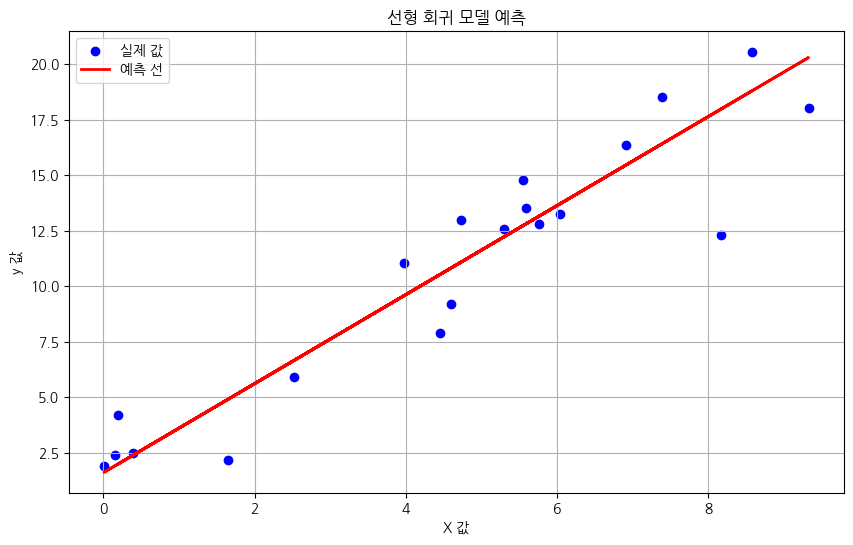

In [65]:
# 5. 결과 시각화
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='실제 값')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='예측 선')
plt.xlabel('X 값')
plt.ylabel('y 값')
plt.title('선형 회귀 모델 예측')
plt.legend()
plt.grid(True)
plt.show()